In [1]:
# Soft-label analysis — convnext_base_22k_certain_only / 01_train_softlabels.csv
# Each column = independent sigmoid P(positive) for that task (multi-label BCE).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV = Path('../../data/chexpert/01_train_softlabels.csv')
TASKS = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']

df = pd.read_csv(CSV)
print('shape      :', df.shape)
print('columns    :', list(df.columns))
print('dup paths  :', df['Path'].duplicated().sum())
print('NaNs/col   :')
print(df[TASKS].isna().sum())
print('prob range :', float(df[TASKS].values.min()), '->', float(df[TASKS].values.max()))
df.head()

shape      : (49938, 6)
columns    : ['Path', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']
dup paths  : 0
NaNs/col   :
Atelectasis         0
Cardiomegaly        0
Consolidation       0
Edema               0
Pleural Effusion    0
dtype: int64
prob range : 0.000556469 -> 0.99726176


,Path,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion
0,CheXpert-v1.0-small/train/patient00002/study2/...,0.202206,0.036734,0.144399,0.101761,0.063382
1,CheXpert-v1.0-small/train/patient00002/study1/...,0.496593,0.035569,0.144287,0.124204,0.643051
2,CheXpert-v1.0-small/train/patient00011/study1/...,0.025454,0.017827,0.081352,0.036737,0.176508
3,CheXpert-v1.0-small/train/patient00011/study4/...,0.124619,0.182044,0.104706,0.118187,0.570295
4,CheXpert-v1.0-small/train/patient00012/study2/...,0.497144,0.009822,0.041904,0.004775,0.053949


In [2]:
# Per-task summary statistics of the soft probabilities
pct = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
stats = df[TASKS].describe(percentiles=pct).T
stats['skew'] = df[TASKS].skew()
stats['mean<0.5%'] = (df[TASKS] < 0.5).mean().values   # fraction predicted negative-leaning
stats = stats[['mean', 'std', 'min', '1%', '5%', '25%', '50%', '75%', '95%', '99%', 'max', 'skew', 'mean<0.5%']]
stats.round(4)

,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,mean<0.5%
Atelectasis,0.2313,0.1624,0.0013,0.0105,0.0287,0.1118,0.2055,0.3111,0.5433,0.7961,0.9908,1.2659,0.9352
Cardiomegaly,0.1238,0.1974,0.0015,0.0042,0.0063,0.0136,0.0320,0.1280,0.6215,0.8652,0.9872,2.2622,0.9237
Consolidation,0.1013,0.0816,0.0014,0.0059,0.0126,0.0416,0.0827,0.1381,0.2543,0.3869,0.8405,1.8018,0.9971
Edema,0.2938,0.2597,0.0006,0.0029,0.0097,0.0646,0.2127,0.4879,0.7950,0.8916,0.9746,0.7142,0.7596
Pleural Effusion,0.4621,0.3244,0.0023,0.0102,0.0225,0.1367,0.4536,0.7701,0.9499,0.9794,0.9973,0.0852,0.5327


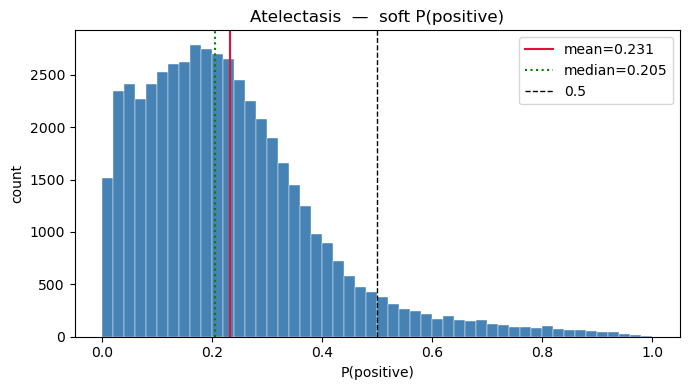

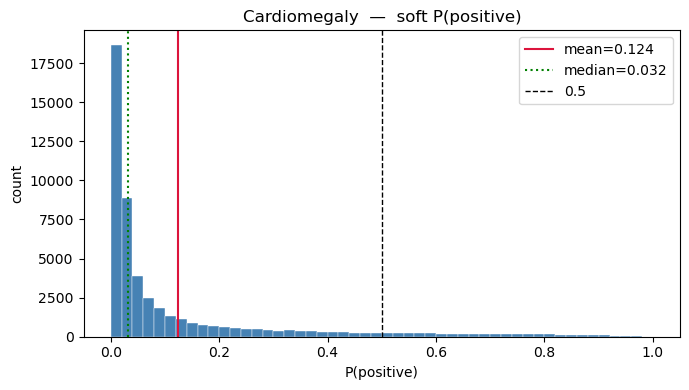

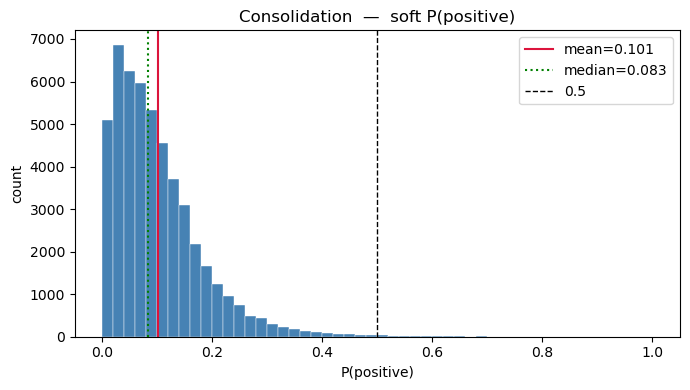

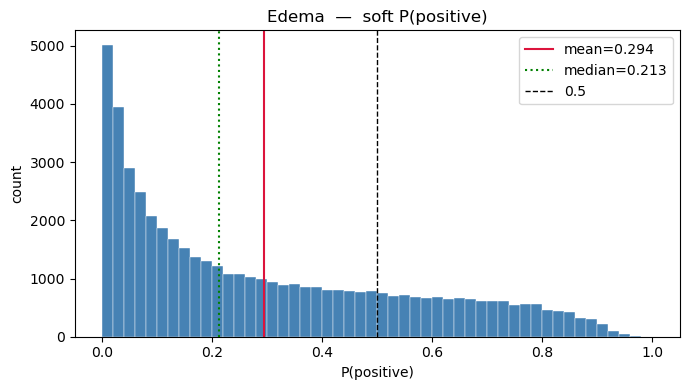

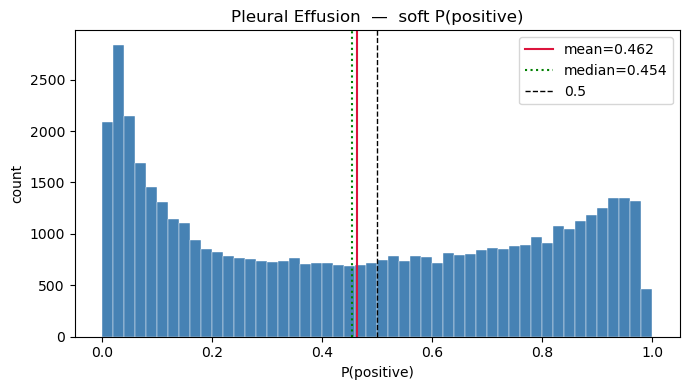

In [4]:
# Per-task histograms of the soft probabilities — one separate figure per task
for t in TASKS:
    v = df[t].values
    plt.figure(figsize=(7, 4))
    plt.hist(v, bins=50, range=(0, 1), color='steelblue', edgecolor='white', linewidth=0.3)
    plt.axvline(v.mean(), color='crimson', lw=1.5, label=f'mean={v.mean():.3f}')
    plt.axvline(np.median(v), color='green', lw=1.5, ls=':', label=f'median={np.median(v):.3f}')
    plt.axvline(0.5, color='black', lw=1.0, ls='--', label='0.5')
    plt.title(f'{t}  —  soft P(positive)')
    plt.xlabel('P(positive)')
    plt.ylabel('count')
    plt.legend()
    plt.tight_layout()
    plt.show()

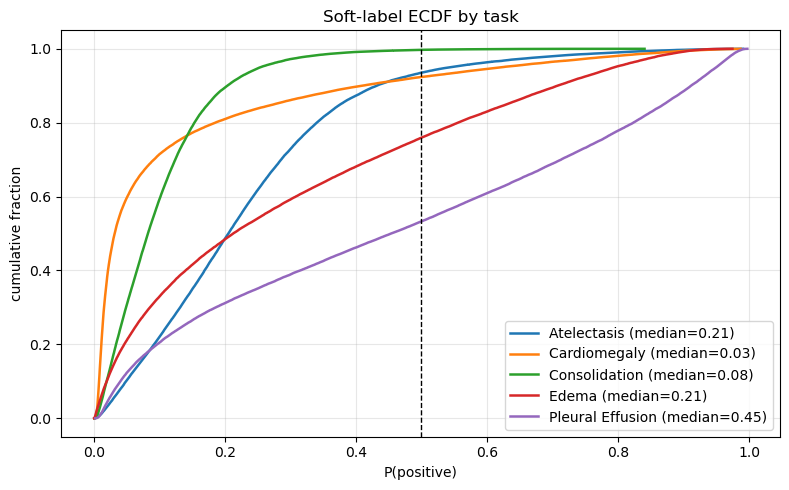

In [5]:
# Combined ECDF — all tasks on one axis (steeper/left = more mass near 0)
plt.figure(figsize=(8, 5))
for t in TASKS:
    x = np.sort(df[t].values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, lw=1.8, label=f'{t} (median={np.median(x):.2f})')
plt.axvline(0.5, color='black', lw=1.0, ls='--')
plt.xlabel('P(positive)')
plt.ylabel('cumulative fraction')
plt.title('Soft-label ECDF by task')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
# How many of the uncertain cases each task would label POSITIVE,
# using two cutoffs: a flat 0.5, and the model's calibrated threshold.
import json
THR_PATH = Path('../../training_scripts/convnext_base_22k_u_selftrain_consol_only/results/thresholds.json')
thr = {}
if THR_PATH.exists():
    raw = json.loads(THR_PATH.read_text())
    thr = raw.get('thresholds', raw)            # support {'thresholds': {...}} or flat
    print('loaded thresholds.json:', {k: round(float(v), 3) for k, v in thr.items() if k in TASKS})
else:
    print('thresholds.json NOT found -> showing the 0.5 cutoff only. '
          'Run calibrate_threshold.py to add the calibrated-cutoff columns.')

n = len(df)
print(f'total uncertain cases analyzed: {n}')
rows = []
for t in TASKS:
    v = df[t].values
    pos05 = int((v >= 0.5).sum())
    row = {
        'task': t,
        'cutoff=0.5': 0.5,
        'n_positive @0.5': pos05,
        '% positive @0.5': f'{100 * pos05 / n:.2f}%',
    }
    if t in thr:
        c = float(thr[t])
        posc = int((v >= c).sum())
        row.update({
            'calibrated cutoff': round(c, 3),
            'n_positive @calibrated': posc,
            '% positive @calibrated': f'{100 * posc / n:.2f}%',
        })
    rows.append(row)
pd.DataFrame(rows).set_index('task')

loaded thresholds.json: {'Atelectasis': 0.25, 'Cardiomegaly': 0.323, 'Consolidation': 0.047, 'Edema': 0.282, 'Pleural Effusion': 0.42}
total uncertain cases analyzed: 49938


,cutoff=0.5,n_positive @0.5,% positive @0.5,calibrated cutoff,n_positive @calibrated,% positive @calibrated
task,,,,,,
Atelectasis,0.5,3235,6.48%,0.250,19146,38.34%
Cardiomegaly,0.5,3810,7.63%,0.323,6488,12.99%
Consolidation,0.5,143,0.29%,0.047,35570,71.23%
Edema,0.5,12006,24.04%,0.282,21302,42.66%
Pleural Effusion,0.5,23336,46.73%,0.420,26131,52.33%


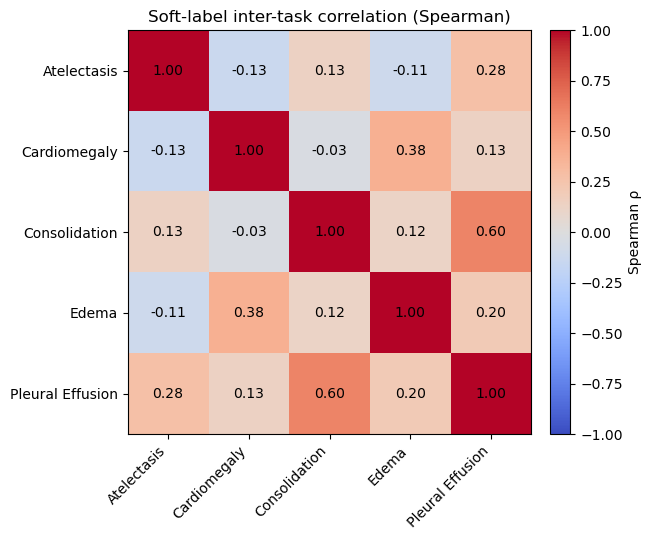

,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion
Atelectasis,1.000,-0.128,0.135,-0.113,0.281
Cardiomegaly,-0.128,1.000,-0.035,0.377,0.133
Consolidation,0.135,-0.035,1.000,0.124,0.596
Edema,-0.113,0.377,0.124,1.000,0.203
Pleural Effusion,0.281,0.133,0.596,0.203,1.000


In [9]:
# Inter-task correlation of the soft labels (Spearman — robust to the skew)
corr = df[TASKS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, rotation=45, ha='right')
ax.set_yticks(range(len(TASKS))); ax.set_yticklabels(TASKS)
for i in range(len(TASKS)):
    for j in range(len(TASKS)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                color='black', fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Spearman ρ')
ax.set_title('Soft-label inter-task correlation (Spearman)')
plt.tight_layout()
plt.show()
corr.round(3)

In [10]:
# Sanity check: most- and least-confident uncertain cases per task
K = 3   # how many examples to show each end
for t in TASKS:
    s = df[['Path', t]].sort_values(t, ascending=False)
    print('=' * 90)
    print(f'{t}   (highest = model most confident POSITIVE, lowest = most confident NEGATIVE)')
    print('-' * 90)
    print(f'  TOP {K}:')
    for _, r in s.head(K).iterrows():
        print(f'    {r[t]:.3f}   {r.Path}')
    print(f'  BOTTOM {K}:')
    for _, r in s.tail(K).iloc[::-1].iterrows():
        print(f'    {r[t]:.3f}   {r.Path}')

Atelectasis   (highest = model most confident POSITIVE, lowest = most confident NEGATIVE)
------------------------------------------------------------------------------------------
  TOP 3:
    0.991   CheXpert-v1.0-small/train/patient44288/study2/view1_frontal.jpg
    0.990   CheXpert-v1.0-small/train/patient02357/study2/view1_frontal.jpg
    0.988   CheXpert-v1.0-small/train/patient22058/study1/view1_frontal.jpg
  BOTTOM 3:
    0.001   CheXpert-v1.0-small/train/patient16890/study1/view1_frontal.jpg
    0.001   CheXpert-v1.0-small/train/patient29527/study1/view1_frontal.jpg
    0.002   CheXpert-v1.0-small/train/patient09530/study4/view1_frontal.jpg
Cardiomegaly   (highest = model most confident POSITIVE, lowest = most confident NEGATIVE)
------------------------------------------------------------------------------------------
  TOP 3:
    0.987   CheXpert-v1.0-small/train/patient23673/study2/view1_frontal.jpg
    0.981   CheXpert-v1.0-small/train/patient41232/study2/view1_frontal.jpg